# Early-Stage Alzheimer's Detection: Non-Demented vs Very Mild Demented (Brain MRI)

## 1. Problem Framing

**Clinical motivation:**  
Alzheimer's disease is progressive, and the clinically hardest boundary is often between:
- **Non-Demented** (no measurable cognitive decline) and  
- **Very Mild Demented** (subtle, early-stage decline).

Missing Very Mild cases (false negatives) is more harmful than over-calling them (false positives), so
our modelling and evaluation will be **sensitivity-focused** for the Very Mild Demented class.

**Task definition (primary):**
- **Binary classification** on brain MRI slices:
  - Class 0: NonDemented
  - Class 1: VeryMildDemented

**Secondary (optional) task:**
- Multiclass classification across all four stages:
  - NonDemented, VeryMildDemented, MildDemented, ModerateDemented

## 2. Dataset description

We use the Kaggle dataset:

> Alzheimer's Disease Multiclass Images Dataset (Equal and Augmented)

Key properties:
- ~44,000 MRI images (JPG)
- 4 folders / classes:
  - `NonDemented/`
  - `VeryMildDemented/`
  - `MildDemented/`
  - `ModerateDemented/`
- Images are skull-stripped (non-brain tissue removed).
- Dataset is **upsampled and augmented** to balance classes.





###**Import data set**

In [1]:
import json

kaggle_config = {
    "username": "vsmuhsina",
    "key": "KGAT_e5969974107c2644f6ae0977bdc841ba"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_config, f)

print("kaggle.json file created")

kaggle.json file created


In [2]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!pip install -q kaggle

In [4]:
!kaggle datasets list

ref                                                             title                                                 size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  ----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset  FIFA World Cup 2026 Player Performance Dataset     4154062  2026-06-10 12:58:47.093000          14070        344                1  
abbas829/ecommerce-sales-dataset                                Ecommerce sales dataset                             110951  2026-07-03 00:59:03.347000           2563         50                1  
deeplumiere/automobile-market-analytics-dataset                 Automobile Market Analytics Dataset                 125437  2026-07-14 07:35:20.707000            816         26                1  
rickyjackson/quebec-

In [5]:
!kaggle datasets download -d aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented

Dataset URL: https://www.kaggle.com/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
License(s): apache-2.0
100% 398M/398M [00:26<00:00, 16.0MB/s]



In [6]:
# Extract ONLY the two classes we need (NonDemented, VeryMildDemented).
# Kaggle's API always downloads the full zip (there's no server-side partial
# download), but we can avoid ever writing the other two classes to disk by
# extracting selectively from the zip, then deleting the zip immediately.
# This keeps disk usage and later RAM usage much lower, which is what was
# crashing the Colab runtime.

import zipfile
import os

ZIP_PATH = "alzheimers-multiclass-dataset-equal-and-augmented.zip"
TARGET_CLASSES = ["NonDemented", "VeryMildDemented"]
EXTRACT_ROOT = "/content"

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    members = [
        m for m in z.namelist()
        if any(f"/{cls}/" in m or m.startswith(f"{cls}/") for cls in TARGET_CLASSES)
    ]
    print(f"Extracting {len(members)} files for classes: {TARGET_CLASSES}")
    z.extractall(path=EXTRACT_ROOT, members=members)

# Free up disk space immediately - we don't need the zip (or the other two
# classes) any more.
os.remove(ZIP_PATH)
print("Deleted zip file to free disk space.")


Extracting 24000 files for classes: ['NonDemented', 'VeryMildDemented']
Deleted zip file to free disk space.


###***STEP 1 — Verify the dataset is downloaded correctly***

In [7]:
import os

DATASET_ROOT = "/content/combined_images"

# We only extracted these two classes from the zip, so just use them
# directly instead of os.listdir (which would also work now, since the
# other two class folders were never extracted).
classes = ["NonDemented", "VeryMildDemented"]
print("Classes found:", classes)

for cls in classes:
    path = os.path.join(DATASET_ROOT, cls)
    print(f"{cls}: {len(os.listdir(path))} images")


Classes found: ['NonDemented', 'VeryMildDemented']
NonDemented: 12800 images
VeryMildDemented: 11200 images


### Build a dataframe of images and labels


In [8]:
from pathlib import Path
import pandas as pd

DATASET_ROOT = Path("/content/combined_images")

records = []

for cls in classes:
    cls_path = DATASET_ROOT / cls
    for img_path in cls_path.glob("*.jpg"):
        records.append({
            "filepath": img_path,
            "filename": img_path.name,
            "label": cls
        })

df = pd.DataFrame(records)
print("Total images:", len(df))
df.head()

Total images: 24000


,filepath,filename,label
0,/content/combined_images/NonDemented/dfc303d0-...,dfc303d0-091c-44aa-afc2-247115a59ac4.jpg,NonDemented
1,/content/combined_images/NonDemented/3e08d3f1-...,3e08d3f1-31d3-42a5-a387-f8b3807fd889.jpg,NonDemented
2,/content/combined_images/NonDemented/2c107e5b-...,2c107e5b-d74c-4585-ad11-a2f83aa5a9b4.jpg,NonDemented
3,/content/combined_images/NonDemented/886fec7d-...,886fec7d-e39b-4051-9169-1cb98408a23d.jpg,NonDemented
4,/content/combined_images/NonDemented/nonDem188...,nonDem1885.jpg,NonDemented


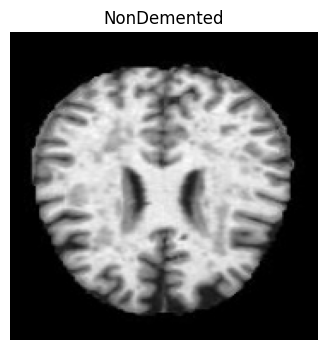

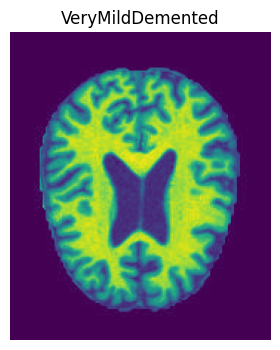

In [9]:
import matplotlib.pyplot as plt
from PIL import Image

for cls in classes:
    # pick the first image from that class
    sample_path = df[df["label"] == cls]["filepath"].iloc[0]

    img = Image.open(sample_path)

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
    plt.show()


### ***Step A: Build the binary subset***

In [10]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd

In [11]:
binary_df = df[df["label"].isin(["NonDemented", "VeryMildDemented"])].copy()
binary_df["label_id"] = binary_df["label"].map({
    "NonDemented": 0,
    "VeryMildDemented": 1
})


In [12]:
binary_df.head()


,filepath,filename,label,label_id
0,/content/combined_images/NonDemented/dfc303d0-...,dfc303d0-091c-44aa-afc2-247115a59ac4.jpg,NonDemented,0
1,/content/combined_images/NonDemented/3e08d3f1-...,3e08d3f1-31d3-42a5-a387-f8b3807fd889.jpg,NonDemented,0
2,/content/combined_images/NonDemented/2c107e5b-...,2c107e5b-d74c-4585-ad11-a2f83aa5a9b4.jpg,NonDemented,0
3,/content/combined_images/NonDemented/886fec7d-...,886fec7d-e39b-4051-9169-1cb98408a23d.jpg,NonDemented,0
4,/content/combined_images/NonDemented/nonDem188...,nonDem1885.jpg,NonDemented,0


In [13]:
binary_df["label"].value_counts()


,count
label,
NonDemented,12800
VeryMildDemented,11200


***Step B — Perform pseudo patient‑level splitting***

In [14]:
binary_df["patient_id"] = binary_df["filename"].apply(lambda x: x.split("_")[0])


In [15]:
from sklearn.model_selection import train_test_split

patients = binary_df["patient_id"].unique()

train_p, temp_p = train_test_split(patients, test_size=0.30, random_state=42)
val_p, test_p = train_test_split(temp_p, test_size=0.50, random_state=42)


In [16]:
import pandas as pd

split_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "num_patients": [len(train_p), len(val_p), len(test_p)]
})

split_summary


,split,num_patients
0,train,16499
1,val,3535
2,test,3536


In [17]:
def assign_split(pid):
    if pid in train_p: return "train"
    elif pid in val_p: return "val"
    else: return "test"

binary_df["split"] = binary_df["patient_id"].apply(assign_split)
binary_df.head()

,filepath,filename,label,label_id,patient_id,split
0,/content/combined_images/NonDemented/dfc303d0-...,dfc303d0-091c-44aa-afc2-247115a59ac4.jpg,NonDemented,0,dfc303d0-091c-44aa-afc2-247115a59ac4.jpg,val
1,/content/combined_images/NonDemented/3e08d3f1-...,3e08d3f1-31d3-42a5-a387-f8b3807fd889.jpg,NonDemented,0,3e08d3f1-31d3-42a5-a387-f8b3807fd889.jpg,train
2,/content/combined_images/NonDemented/2c107e5b-...,2c107e5b-d74c-4585-ad11-a2f83aa5a9b4.jpg,NonDemented,0,2c107e5b-d74c-4585-ad11-a2f83aa5a9b4.jpg,train
3,/content/combined_images/NonDemented/886fec7d-...,886fec7d-e39b-4051-9169-1cb98408a23d.jpg,NonDemented,0,886fec7d-e39b-4051-9169-1cb98408a23d.jpg,val
4,/content/combined_images/NonDemented/nonDem188...,nonDem1885.jpg,NonDemented,0,nonDem1885.jpg,train


***Step C — Preprocess images (resize + normalize)***

In [18]:
IMG_SIZE = (224, 224)

def preprocess_image(path):
    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE)
    # float32 instead of the float64 default - halves RAM usage for the
    # X_train / X_val / X_test arrays, which is important since we're
    # loading thousands of images fully into memory at once.
    return (np.array(img) / 255.0).astype(np.float32)


***Step D — Build NumPy datasets***

train: 16784 | val: 3596 | test: 3620


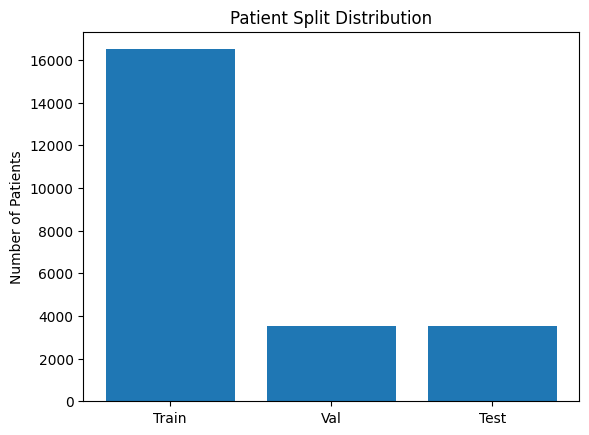

In [19]:

train_df = binary_df[binary_df["split"] == "train"]
val_df   = binary_df[binary_df["split"] == "val"].reset_index(drop=True)
test_df  = binary_df[binary_df["split"] == "test"].reset_index(drop=True)

print(f"train: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}")


# We still need plain numpy label arrays for sklearn metrics later.
# val_df / test_df are NOT shuffled, so this order matches model.predict(test_ds).
y_val  = val_df["label_id"].values
y_test = test_df["label_id"].values
import matplotlib.pyplot as plt

plt.bar(["Train", "Val", "Test"], [len(train_p), len(val_p), len(test_p)])
plt.title("Patient Split Distribution")
plt.ylabel("Number of Patients")
plt.show()


In [20]:
import tensorflow as tf
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label

def make_dataset(df, shuffle=False, batch_size=BATCH_SIZE):
    paths = df["filepath"].astype(str).tolist()
    labels = df["label_id"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_df = binary_df[binary_df["split"] == "train"]
val_df   = binary_df[binary_df["split"] == "val"].reset_index(drop=True)
test_df  = binary_df[binary_df["split"] == "test"].reset_index(drop=True)

print(f"train: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}")

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

# We still need plain numpy label arrays for sklearn metrics later.
# val_df / test_df are NOT shuffled, so this order matches model.predict(test_ds).
y_val  = val_df["label_id"].values
y_test = test_df["label_id"].values

train: 16784 | val: 3596 | test: 3620


# Phase 3 – Baseline CNN for Early-Stage Alzheimer's Detection

We now train a **simple CNN baseline** to:

- Establish a performance floor for the binary task:
  - Class 0: NonDemented
  - Class 1: VeryMildDemented
- Check if the dataset and preprocessing are sane.
- Prepare for later comparison with transfer learning models.

We will:
- Use a 3–4 layer CNN.
- Train with `binary_crossentropy`.
- Evaluate accuracy, precision, recall, F1.
- Inspect a confusion matrix and ROC curve.


In [43]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = IMG_SIZE + (3,)  # (224, 224, 3)

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

   layers.GlobalAveragePooling2D(),
layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")  # binary output
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

***Compile & train with callbacks***

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)


Epoch 1/30
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - accuracy: 0.6388 - loss: 0.6267 - val_accuracy: 0.7094 - val_loss: 0.5540 - learning_rate: 1.0000e-04
Epoch 2/30
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 34s 32ms/step - accuracy: 0.7512 - loss: 0.5010 - val_accuracy: 0.7778 - val_loss: 0.4539 - learning_rate: 1.0000e-04
Epoch 3/30
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 34s 32ms/step - accuracy: 0.8194 - loss: 0.3797 - val_accuracy: 0.8462 - val_loss: 0.3419 - learning_rate: 1.0000e-04
Epoch 4/30
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 35s 33ms/step - accuracy: 0.8717 - loss: 0.2848 - val_accuracy: 0.8826 - val_loss: 0.2618 - learning_rate: 1.0000e-04
Epoch 5/30
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 43s 35ms/step - accuracy: 0.9009 - loss: 0.2199 - val_accuracy: 0.8660 - val_loss: 0.2856 - learning_rate: 1.0000e-04
Epoch 6/30
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 35s 33ms/step - accuracy: 0.9211 - loss: 0.1805 - val_accuracy: 0.9018 - val_loss: 0.2199 - learning_rate: 1.0000e-04
Epoch 7/30
1049/1049 ━━━━━━━━━━━━━━━━━━━

***Plot training curves***

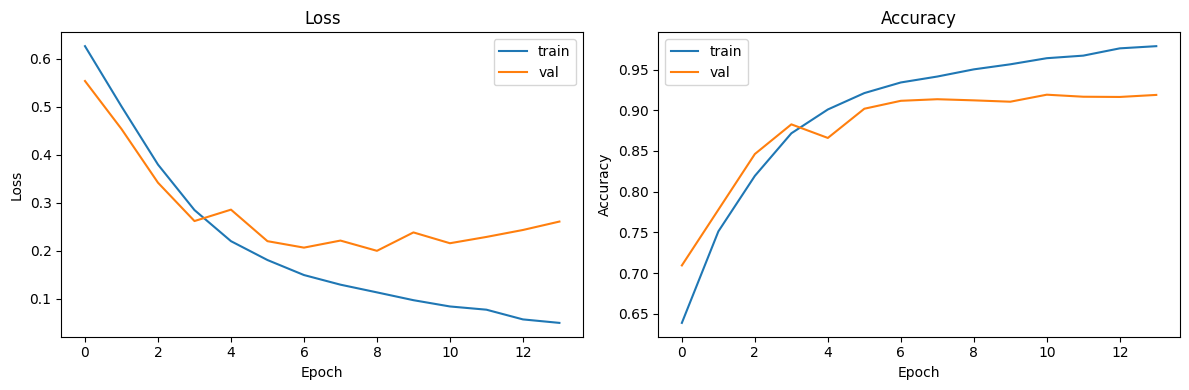

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
history = model.fit(train_ds, validation_data=val_ds, epochs=13)
history.history['accuracy']        # training accuracy per epoch
history.history['val_accuracy']    # validation accuracy per epoch
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])



Epoch 1/13
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 36s 35ms/step - accuracy: 0.9656 - loss: 0.0810 - val_accuracy: 0.9191 - val_loss: 0.2239
Epoch 2/13
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 34s 33ms/step - accuracy: 0.9703 - loss: 0.0694 - val_accuracy: 0.9152 - val_loss: 0.2393
Epoch 3/13
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 36s 34ms/step - accuracy: 0.9735 - loss: 0.0634 - val_accuracy: 0.9182 - val_loss: 0.2494
Epoch 4/13
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.9735 - loss: 0.0587 - val_accuracy: 0.9191 - val_loss: 0.2458
Epoch 5/13
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 35s 33ms/step - accuracy: 0.9781 - loss: 0.0513 - val_accuracy: 0.9130 - val_loss: 0.2813
Epoch 6/13
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9771 - loss: 0.0513 - val_accuracy: 0.9199 - val_loss: 0.2915
Epoch 7/13
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 34s 33ms/step - accuracy: 0.9799 - loss: 0.0435 - val_accuracy: 0.9143 - val_loss: 0.3161
Epoch 8/13
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 36s 35ms/step - accuracy: 0.9811 -

In [25]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)


227/227 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.9254 - loss: 0.3300
Test Accuracy: 0.9254143834114075


***Evaluation: accuracy, precision, recall, F1***

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)
import numpy as np

# Predict probabilities on test set
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)  # sensitivity for VeryMildDemented (class 1)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")


227/227 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step
Accuracy:  0.9254
Precision: 0.9184
Recall:    0.9184
F1-score:  0.9184


***Confusion matrix***

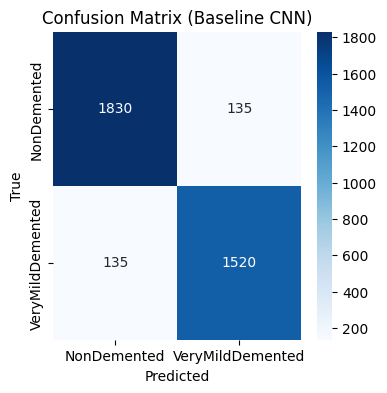

In [27]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NonDemented", "VeryMildDemented"],
            yticklabels=["NonDemented", "VeryMildDemented"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Baseline CNN)")
plt.show()



Accuracy alone is misleading for medical tasks.

For early-stage Alzheimer's detection, the **costliest clinical error** is:
- **False Negative** → predicting "NonDemented" when the patient is actually "VeryMildDemented".

Therefore, we emphasize:
- **Recall (Sensitivity)** for VeryMildDemented
- **Precision**
- **F1-score**
- **Confusion Matrix**
- **ROC Curve**
- **AUC (Area Under Curve)**

These metrics show how well the model detects early cognitive decline.

***ROC curve***

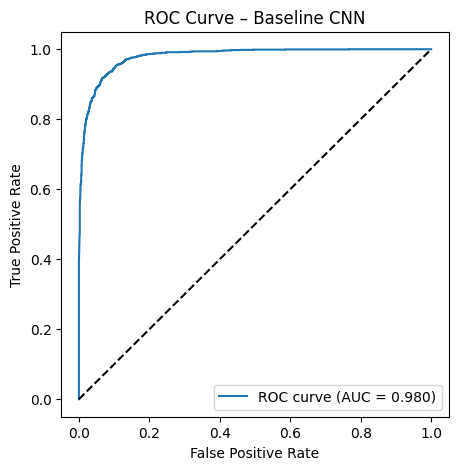

In [28]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Baseline CNN")
plt.legend(loc="lower right")
plt.show()


 — Clinical Evaluation Metrics

Accuracy alone is misleading for medical tasks.

For early-stage Alzheimer's detection, the **costliest clinical error** is:
- **False Negative** → predicting "NonDemented" when the patient is actually "VeryMildDemented".

Therefore, we emphasize:
- **Recall (Sensitivity)** for VeryMildDemented
- **Precision**
- **F1-score**
- **Confusion Matrix**
- **ROC Curve**
- **AUC (Area Under Curve)**

These metrics show how well the model detects early cognitive decline.


 Summary of Phase 5

The model is evaluated using metrics relevant to early Alzheimer's detection:

### ✔ Accuracy
Shows overall correctness, but not enough for clinical use.

### ✔ Precision
Indicates how reliable the model is when it predicts VeryMildDemented.

### ✔ Recall (Sensitivity)
**Most important metric.**
Measures how many early-stage dementia cases the model successfully detects.

### ✔ F1-score
Balances precision and recall.

### ✔ Confusion Matrix
Shows the distribution of clinical errors (FN vs FP).

### ✔ ROC-AUC
Measures overall separability between NonDemented and VeryMildDemented.

A clinically useful model should:
- Have **high recall** for VeryMildDemented.
- Keep **false negatives low**.
- Show a strong ROC-AUC (>0.85 is good, >0.90 is excellent).


In [45]:
model.save(
    "alzheimer_model.keras",
    include_optimizer=False
)

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

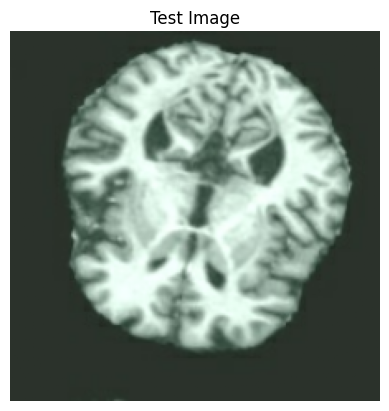

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Take one batch from the test dataset
for batch_imgs, batch_labels in test_ds.take(1):
    break

# Pick one image from the batch
i = 10   # choose any index inside the batch
sample = batch_imgs[i].numpy()
true_label = batch_labels[i].numpy()

## to show the image
plt.imshow(sample)
plt.title("Test Image")
plt.axis("off")


In [32]:
#Prepare the image for prediction
sample_input = np.expand_dims(sample, axis=0)   # shape becomes (1, 224, 224, 3)
# — Predict
pred = model.predict(sample_input)
pred_class = int(np.round(pred[0]))   # because binary label_id is 0 or 1

#get the true label
print("Predicted class:", pred_class)
print("Actual class:", int(true_label))

class_names = ["Normal", "Alzheimer"]

print("Predicted:", class_names[pred_class])
print("Actual:", class_names[int(true_label)])




1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 860ms/step
Predicted class: 0
Actual class: 0
Predicted: Normal
Actual: Normal


/tmp/ipykernel_877/4193374075.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_class = int(np.round(pred[0]))   # because binary label_id is 0 or 1


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

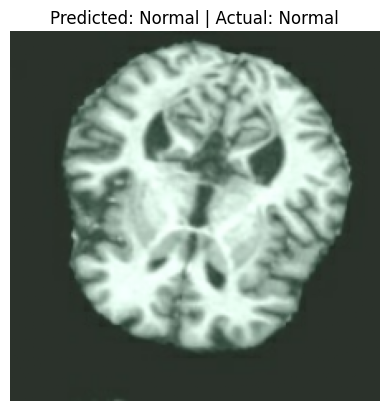

In [33]:
# show prediction on the image
plt.imshow(sample)
plt.title(f"Predicted: {class_names[pred_class]} | Actual: {class_names[int(true_label)]}")
plt.axis("off")



# Phase 4 — Explainability with Grad-CAM

Deep learning models are often criticized for being "black boxes."
Grad-CAM (Gradient-weighted Class Activation Mapping) helps us visualize:

- Which regions of the MRI slice influenced the model's decision.
- Whether the model attends to clinically relevant areas:
  - Hippocampus
  - Medial temporal lobe
  - Ventricular enlargement

This is essential for:
- Clinical trust
- Model debugging
- Demonstrating that the model is not learning artifacts


***Grad‑CAM Utility Function***


This works for any Keras model, including your ResNet50 fine‑tuned model.

In [34]:
def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found.")

last_conv_layer_name = find_last_conv_layer(model)
print("Last Conv Layer:", last_conv_layer_name)


Last Conv Layer: conv2d_2


In [35]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]   # binary output neuron

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


In [36]:


def display_gradcam(original_img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap_color * alpha + original_img * (1 - alpha)

    plt.figure(figsize=(6,6))
    plt.imshow(superimposed_img.astype("uint8"))
    plt.axis("off")


In [37]:
# Get one batch
for batch_imgs, batch_labels in test_ds.take(1):
    break

i = 1  # pick any image
sample = batch_imgs[i].numpy()
true_label = int(batch_labels[i].numpy())


In [38]:
sample_input = np.expand_dims(sample, axis=0)

pred = model.predict(sample_input)[0][0]
pred_class = int(np.round(pred))

print("Predicted:", pred_class)
print("Actual:", true_label)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted: 0
Actual: 0


# Grad-CAM Interpretation

A clinically meaningful Grad-CAM heatmap should highlight:

### ✔ Hippocampal region  
Early Alzheimer's is strongly associated with hippocampal atrophy.

### ✔ Medial temporal lobe  
This region shows early structural changes.

### ✔ Ventricular enlargement  
Often visible in early cognitive decline.

### What we DO NOT want:
- Heatmaps focusing on skull edges
- Heatmaps focusing on background noise
- Heatmaps focusing on text or artifacts

If the model attends to clinically relevant regions, it suggests:
- The model is learning meaningful anatomical patterns.
- The classification is not driven by dataset artifacts.
